In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[28.12597332]
-2.2710144261783825


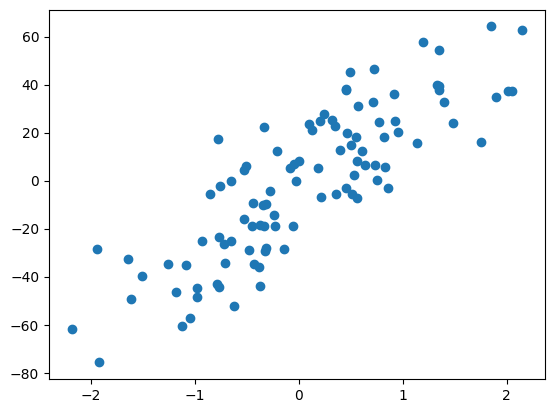

In [2]:
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1 , noise=20, random_state=13)
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2, random_state=2)

plt.scatter(x,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(xtrain, ytrain)
print(reg.coef_)
print(reg.intercept_)

C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)


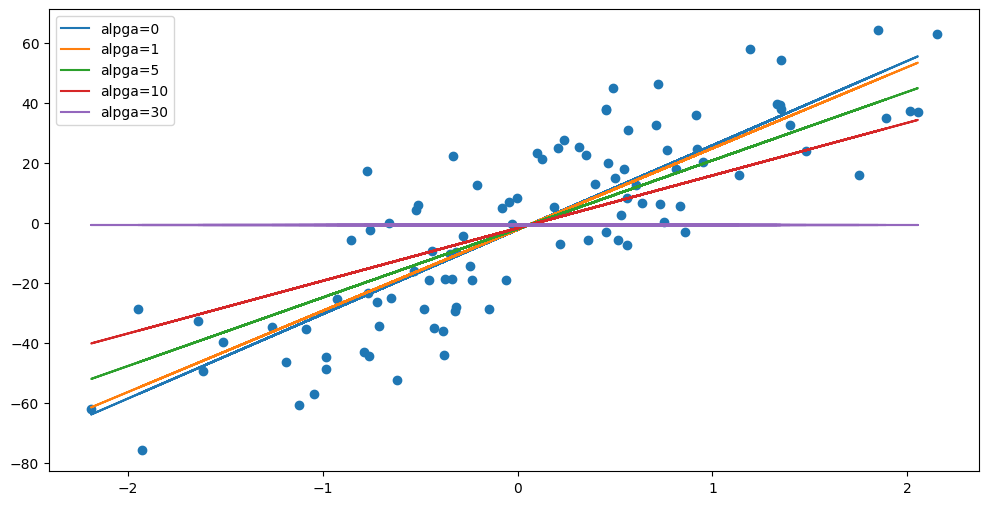

In [5]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(x,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(xtrain, ytrain)
    plt.plot(xtrain, L.predict(xtrain), label = "alpga={}".format(i))
plt.legend()
plt.show()



In [ ]:
# in above graph we can see at alpha = 30 the slope became 0
# in conclusion we caan say that in Lasso the coeffs can got to 0 


C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.219403e+06, tolerance: 8.397e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number 

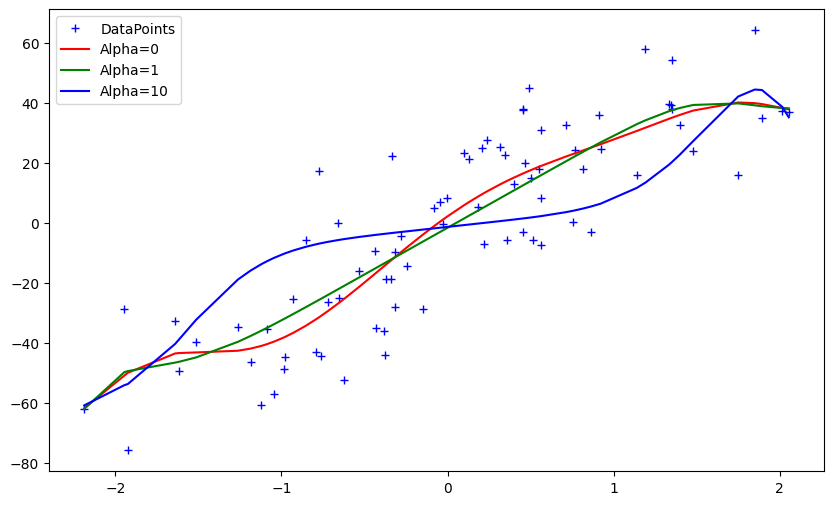

In [8]:
# polynonmial fiittng with lasso

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge


def get_preds_lasso(x1,x2,alpha):
    model = Pipeline([
        ('poly_feats' , PolynomialFeatures(degree=16)),
        ('lasso' , Lasso(alpha=alpha))
    ])
    
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0 , 1, 10]
cs = ['r' , 'g', 'b']

plt.figure(figsize=(10,6))
plt.plot(xtrain, ytrain, 'b+' , label= 'DataPoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(xtrain, ytrain, alpha)
    plt.plot(sorted(xtrain[: , 0]) , preds[np.argsort(xtrain[:, 0])] , c , label='Alpha={}'.format(alpha))
    
plt.legend()
plt.show()
    